In [78]:
import pandas as pd

In [79]:
df_raw = pd.read_csv("ai4i2020.csv")
df_raw.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [80]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

## Variablenübersicht – AI4I 2020 Dataset

| Variable             | Beschreibung (Englisch)            | Deutscher Begriff / Erklärung                  |
|----------------------|------------------------------------|------------------------------------------------|
| **UDI**              | Unique identifier                 | Eindeutige Laufnummer (ID, nicht als Feature nutzen) |
| **Product ID**       | Product serial number (letters & digits) | Produkt-ID (Typ/Charge, Metadaten)             |
| **Type**             | Machine type (L, M, H)             | Maschinentyp (Low/Medium/High load)            |
| **Air temperature [K]** | Ambient air temperature (Kelvin) | Lufttemperatur [K]                             |
| **Process temperature [K]** | Process temperature (Kelvin) | Prozesstemperatur [K]                          |
| **Rotational speed [rpm]** | Rotational speed (revolutions per minute) | Drehzahl [U/min]                        |
| **Torque [Nm]**      | Torque (Newton meter)             | Drehmoment [Nm]                                |
| **Tool wear [min]**  | Tool wear in minutes              | Werkzeugverschleiß [min]                       |

Zielvariablen / Labels

| Variable             | Beschreibung (Englisch)            | Deutscher Begriff / Erklärung                  |
|----------------------|------------------------------------|------------------------------------------------|
| **Machine failure**  | Machine failed? (0/1)              | Maschinenausfall (Zielvariable, binär)         |
| **TWF**              | Tool wear failure                 | Werkzeugverschleiß-Ausfall                     |
| **HDF**              | Heat dissipation failure          | Wärmeabfuhr-Ausfall                            |
| **PWF**              | Power failure                     | Strom-/Leistungsausfall                        |
| **OSF**              | Overstrain failure                | Überlastungs-Ausfall                           |
| **RNF**              | Random failure                    | Zufälliger Ausfall                             |

## Statistische Übersicht
- Prüfung der numerischen Werte auf Mittellwert, Standardabweichung und Wertebereiche
- Hilft Ausreißer oder fehlerhafte Werte zu erkennen
- hier können wir sehen, ob Werte eventuell nicht der Norm entsprechen (Ausreißer)

In [82]:
df_raw.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [83]:
for col in ['Air temperature [K]','Process temperature [K]',
            'Rotational speed [rpm]','Torque [Nm]','Tool wear [min]']:
    print(col, df_raw[col].min(), df_raw[col].max())

Air temperature [K] 295.3 304.5
Process temperature [K] 305.7 313.8
Rotational speed [rpm] 1168 2886
Torque [Nm] 3.8 76.6
Tool wear [min] 0 253


### Sanity Check der Wertebereiche
- **Lufttemperatur:** 22–31 °C → realistische Umgebungstemperaturen
- **Prozesstemperatur:** 32–41 °C → logisch etwas höher als Luft
- **Drehzahl:** 1.100–2.900 rpm → typisch für Werkzeugmaschinen
- **Drehmoment:** 4–77 Nm → plausibel, vergleichbar mit Akkuschrauber bis Werkzeugspindel
- **Werkzeugverschleiß:** 0–253 min (~4h) → plausibel für simulierten Betrieb

Keine auffälligen oder unplausiblen Werte gefunden.

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


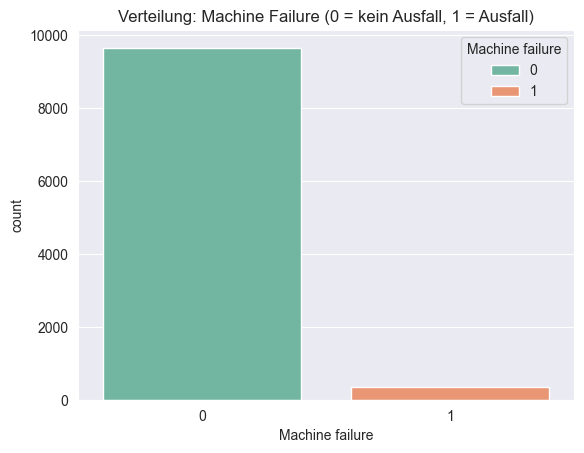

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hauptzielvariable
print(df_raw['Machine failure'].value_counts(normalize=True))

sns.countplot(x="Machine failure", data=df_raw, palette="Set2", hue=df["Machine failure"])
plt.title("Verteilung: Machine Failure (0 = kein Ausfall, 1 = Ausfall)")
plt.show()

hier sehen wir dass wir sehr wenige Ausfalldaten haben aber viele ohne Ausfall.. also das ist ja realistisch und theoretisch gut aber wir haben das Problem dass wir für das Training gleich viele Daten brauchen, damit das Modell keinen Bias hat und Ausfälle gut erkennen kann

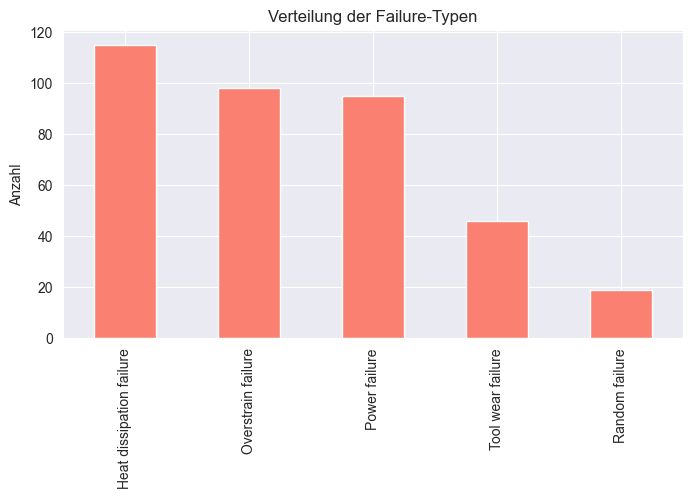

In [73]:
failure_cols = {
    "TWF": "Tool wear failure",
    "HDF": "Heat dissipation failure",
    "PWF": "Power failure",
    "OSF": "Overstrain failure",
    "RNF": "Random failure"
}

# alle cols als liste, da keine Operation auf dem Objekt möglich ist, dann nur die keys nehmen..
sorted_failure_cols = df_raw[list(failure_cols.keys())].sum().sort_values(ascending=False)

# sorgt dafür, dass die Spalten eine ausführlichere Beschreibung haben
renamed_sorted_failure_cols = sorted_failure_cols.rename(index=failure_cols)

renamed_sorted_failure_cols.plot(kind="bar", figsize=(8,4), color="salmon")
plt.title("Verteilung der Failure-Typen")
plt.ylabel("Anzahl")
plt.show()

Auch beim näheren analysieren sehen wir, dass wir eine ungleiche Verteilung der Failure Typen haben.
Rein Analysetechnisch ist das gut, dass wir erfahren dass die am ehesten vorkommende Heat dissipation failure ist.

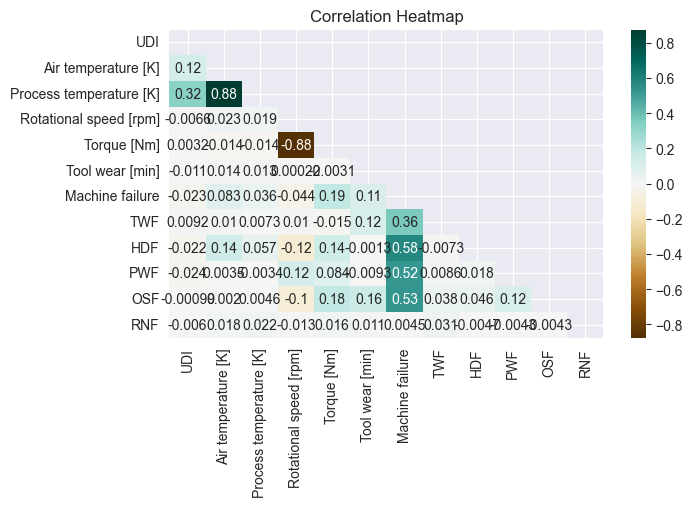

In [74]:
import numpy as np

# create new df_analyze for correlation
df_analyze = df_raw.drop(columns=["Product ID","Type"])

# Correlation Heatmap
plt.figure(figsize=(7,4))
sns.heatmap(data=df_analyze.corr(), mask=np.triu(df_analyze.corr()), annot=True, cmap='BrBG')
plt.title('Correlation Heatmap')
plt.show()


1.	Ziel: Erst ein Binärmodell bauen (Machine failure)
2. Dann Explainability (z. B. SHAP), um zu verstehen, welche Features die Vorhersagen treiben.
3. Mit den Erkenntnissen → Hypothesen für „Warum fällt die Maschine aus?“.

In [88]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, confusion_matrix, \
    classification_report
from sklearn.metrics import f1_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier

# 1) Features/Target definieren (IDs/Targets droppen)
df_raw = df  # falls bereits geladen
target = "Machine failure"

cat_cols = ["Type"]
num_cols = ["Air temperature [K]","Process temperature [K]",
            "Rotational speed [rpm]","Torque [Nm]","Tool wear [min]"]

# Optional: abgeleitete Features
def add_derived(df):
    df = df.copy()
    df["Temp diff [K]"] = df["Process temperature [K]"] - df["Air temperature [K]"]
    return df

df2 = add_derived(df_raw)
num_cols_ext = num_cols + ["Temp diff [K]"]

X = df2[cat_cols + num_cols_ext].copy()
y = df2[target].astype(int).copy()

# 2) Einheitliche Vorverarbeitung
# - OneHotEncoder(sparse=False) -> dichte Matrix, kompatibel mit HGB
pre = ColumnTransformer([
    ('num', StandardScaler(), num_cols_ext),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# 3) Modellkandidaten
models = {
    "LogReg (balanced)": LogisticRegression(max_iter=4000, class_weight='balanced', n_jobs=-1, solver='liblinear'),
    "RandomForest (balanced)": RandomForestClassifier(
        n_estimators=400, max_depth=None, random_state=0, n_jobs=-1, class_weight='balanced'
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=0),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=0)
}

# 4) CV-Evaluierung (PR-AUC, ROC-AUC, F1@best-threshold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

results = []
proba_cache = {}  # optional: falls du später noch Threshold-Analysen machen willst

for name, est in models.items():
    pipe = Pipeline([("pre", pre), ("clf", est)])
    # Wahrscheinlichkeiten: für SVC-calibrated liefert predict_proba
    # cross_val_predict generiert Out-of-fold-Probabilitäten (fairer Vergleich)
    y_proba = cross_val_predict(pipe, X, y, cv=skf, method="predict_proba", n_jobs=-1)[:, 1]
    proba_cache[name] = y_proba

    pr_auc = average_precision_score(y, y_proba)  # entspricht PR-AUC
    roc = roc_auc_score(y, y_proba)

    # Best Threshold nach F1 (global, aus OOF-Probas)
    p, r, th = precision_recall_curve(y, y_proba)
    f1 = 2 * (p * r) / (p + r + 1e-12)
    best_idx = np.nanargmax(f1)
    best_th = th[max(best_idx - 1, 0)]
    y_pred = (y_proba >= best_th).astype(int)
    f1_best = f1[best_idx]
    cm = confusion_matrix(y, y_pred)

    print(f"\n=== {name} ===")
    print(f"PR-AUC (AP): {pr_auc:.4f} | ROC-AUC: {roc:.4f} | Schwelle: {best_th:.3f}")
    print(classification_report(y, y_pred, digits=3))

    # Confusion-Matrix plotten
    plt.figure(figsize=(3.2, 2.8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    results.append({
        "Model": name,
        "PR-AUC (AP)": pr_auc,
        "ROC-AUC": roc,
        "Best Threshold (F1)": best_th,
        "F1@BestTh": f1_best,
        "confusion matrix": cm
    })

results_df = pd.DataFrame(results).sort_values(by="PR-AUC (AP)", ascending=False)
results_df


/Users/sabrina/Development/PredictiveMaintenance/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 10.
  warnings.warn(
/Users/sabrina/Development/PredictiveMaintenance/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 10.
  warnings.warn(
/Users/sabrina/Development/PredictiveMaintenance/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 10.
  warnings.warn(
/Users/sabrina/Development/PredictiveMaintenance/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 10.
  warnings.warn(
/Users/sabri

,Model,PR-AUC (AP),ROC-AUC,Best Threshold (F1),F1@BestTh
3,HistGradientBoosting,0.857904,0.978886,0.290393,0.807988
2,GradientBoosting,0.838154,0.975721,0.277826,0.810976
1,RandomForest (balanced),0.833172,0.969053,0.342500,0.800638
0,LogReg (balanced),0.423415,0.900495,0.877619,0.446402
